# Model characterisation 2 (260715): reward decomposition

To be run on competitive trained model sims (initially `2607/260715`), not the tournament data. Penalty break was present in this training build, so `trialRewards` here reflect the reward landscape the models were trained under (with free resting).

**Goal:** decompose each model's reward and quantify what the **no-movement penalty-break** contributes — i.e. how much reward each model keeps by resting for free, and whether that disproportionately rewards the peripheral strategy.

Per trial (winner-take-all): **score** = terminal 1.0 High / 0.4 Low / 0. **reward** (`trialRewards`) = score − `step_penalty` × (**action** steps); resting steps are exempt (break present). So:
- **penalty cost** = score − reward = `step_penalty` × action steps (what movement/scanning cost).
- **break saving** = `step_penalty` × resting steps = the penalty they avoided by resting = the break's contribution. Equivalently, if the break were absent (every step penalised) their reward would be lower by this amount.

Both agents are the same model (self-play), so we pool them.

In [1]:
import os
import io
import contextlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

import data_strings
import globals
from parse_data import prepare_sim_data, identify_sim_filepaths
import data_extraction.get_indices as get_indices

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 220)

SIM_DATA_FOLDER = os.path.join(data_strings.SIM_DATA_FOLDER, '2607', '260715')
STEP_PENALTY = 0.001                    # verified from the training config; reward = score - STEP_PENALTY * action_steps
ARENA_RADIUS = 36.21 / 2
PLAYERS = (0, 1)

# the 8 shortlisted models and their strategy band (from model_characterisation_demo)
SHORTLIST = {22: 'central', 20: 'central', 2: 'central',
             14: 'intermediate', 10: 'intermediate',
             36: 'peripheral', 15: 'peripheral', 26: 'peripheral'}
STRAT_ORDER = ['central', 'intermediate', 'peripheral']
STRAT_PALETTE = {'central': '#4C72B0', 'intermediate': '#55A868', 'peripheral': '#DD8452'}

def band(cent):                          # strategy band from mean slice-onset centrality
    return 'central' if cent > 0.55 else ('intermediate' if cent > 0.2 else 'peripheral')

## Per-model reward decomposition

For each model, over its whole self-play session (both agents pooled): mean score, mean reward, the penalty cost paid, and the break saving (penalty avoided by resting). Action steps are recovered as `(score - reward) / step_penalty`; resting steps are the remaining frames.

In [2]:
def slice_onset_centrality(trial, pid):
    """ Return one agent's centrality at slice onset (1 = centre, 0 = wall), or None if missing.
        Takes a trial and player id. """
    try:
        x, z = get_indices.get_player_slice_onset_loc(trial, pid)
        x, z = float(x), float(z)
    except (IndexError, ValueError):
        return None                                          # trial missing a slice-onset frame
    if np.isnan(x) or np.isnan(z):
        return None
    return 1 - np.hypot(x, z) / ARENA_RADIUS # length of vector from centre normalised by arena radius


def decompose_model(model):
    """ Return one row of reward decomposition for a model's self-play session, pooling both agents.
        Takes a model number. """
    with contextlib.redirect_stdout(io.StringIO()):          # mute the loader's per-file prints
        df, trials = prepare_sim_data.prepare_single_model_data(model, sim_data_folder=SIM_DATA_FOLDER)

    TN = globals.TRIAL_NUM
    # decision frames per trial: every logged row carries a trialNum, and (checked) event rows also carry
    # position, so a plain row count equals the ~50 Hz decision-step count for that trial
    frames_per_trial = df.groupby(TN).size()
    te = df[df['eventDescription'] == globals.TRIAL_END].dropna(subset=[TN])   # one row per completed trial
    ## explain how this mapping works and what it's doing
    frames = te[TN].map(frames_per_trial).to_numpy(float)    # frames belonging to each completed trial
    n = len(te)

    # average centrality across all trials and both agents in a single model simulation
    cent = [slice_onset_centrality(t, p) for t in trials for p in PLAYERS]
    cent = float(np.mean([c for c in cent if c is not None])) 

    scores, rewards, costs, savings = [], [], [], []
    for pid, (score_col, reward_col) in {0: (globals.PLAYER_0_TRIAL_SCORE, globals.PLAYER_0_TRIAL_REWARD),
                              1: (globals.PLAYER_1_TRIAL_SCORE, globals.PLAYER_1_TRIAL_REWARD)}.items():
        s = te[score_col].astype(float).to_numpy()                # terminal score per trial (1.0 High / 0.4 Low / 0)
        r = te[reward_col].astype(float).to_numpy()                # logged reward per trial (score net of step penalties)
        # penalised (non-rest) steps per trial, recovered from reward: reward = score - STEP * action_steps
        action_steps = (s - r) / STEP_PENALTY
        # resting steps = frames that were not penalised. Difference at the session level (sum then subtract),
        # not per trial. MLAgents considers the previous ITI to attach with the next trial, and my logging considers
        # the following ITI to attach with the next trial. So, pooling to avoid confusion
        rest_steps = max(0.0, frames.sum() - action_steps.sum()) # this sums over trials
        scores.append(s.mean()); rewards.append(r.mean())
        costs.append((s - r).mean())                         # penalty cost / trial = STEP * action_steps (exact)
        savings.append(STEP_PENALTY * rest_steps / n)        # break saving / trial = penalty avoided by free resting
    # pool the two agents (same model in self-play) into one per-model row
    return dict(model=model, centrality=cent, strategy=band(cent),
                mean_score=np.mean(scores), mean_reward=np.mean(rewards),
                penalty_cost=np.mean(costs), break_saving=np.mean(savings))


# run every model; models with no usable trials (e.g. dead runs 18/19) raise in the loader and are skipped
models = [m for m, _ in identify_sim_filepaths.get_model_folders(sim_data_folder=SIM_DATA_FOLDER)]
records = []
for m in models:
    try:
        records.append(decompose_model(m))
        print(f"model {m:2d} done", end='  ')
    except Exception as e:
        print(f"\nmodel {m} SKIPPED ({type(e).__name__})")
fp = pd.DataFrame(records)
# what each model would earn if the break were absent (every step penalised) = actual reward minus the break refund
fp['reward_no_break'] = fp['mean_reward'] - fp['break_saving']
print(f"\n\nusable models: {len(fp)}")
fp.round(3)

model  1 done  

model  2 done  

model  3 done  

model  4 done  

model  5 done  

...

model 36 done  

model 37 done  

model 38 done  

model 39 done  

usable models: 37


,model,centrality,strategy,mean_score,mean_reward,penalty_cost,break_saving,reward_no_break
0,1,0.861,central,0.453,0.026,0.427,0.032,-0.006
1,2,0.856,central,0.456,0.024,0.432,0.031,-0.007
2,3,-0.038,peripheral,0.364,0.058,0.307,0.154,-0.097
3,4,0.008,peripheral,0.367,0.125,0.242,0.228,-0.103
4,5,0.001,peripheral,0.396,0.253,0.144,0.334,-0.081
5,6,0.037,peripheral,0.414,0.170,0.244,0.236,-0.066
6,7,-0.045,peripheral,0.399,0.085,0.314,0.154,-0.069
7,8,0.002,peripheral,0.394,0.034,0.360,0.106,-0.072
8,9,0.867,central,0.438,0.006,0.432,0.028,-0.022
9,10,0.382,intermediate,0.435,0.194,0.241,0.260,-0.066


## Does the penalty-break favour the peripheral strategy?

Group by strategy. If the break disproportionately rewards resting, peripheral models should show a much larger **break saving** than central ones — meaning the break makes the peripheral strategy more rewarding than it would otherwise be (a candidate reason RL agents, and players, adopt it).

Per-strategy reward decomposition (mean over models):
               n  mean_score  mean_reward  penalty_cost  break_saving  reward_no_break
strategy                                                                              
central       16       0.456        0.029         0.427         0.035           -0.006
intermediate   1       0.435        0.194         0.241         0.260           -0.066
peripheral    20       0.407        0.099         0.309         0.172           -0.073
(summary bar omits under-sampled bands ['intermediate'] (<3 models) - shown per-model in the right panel)


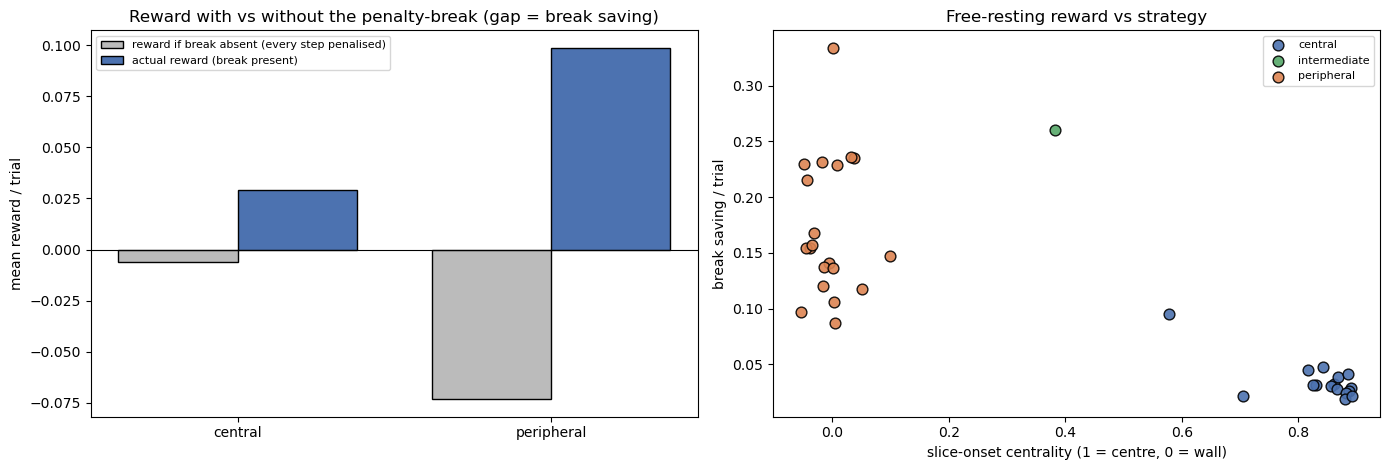

In [3]:
# collapse to per-strategy means (each model contributes equally)
by_strat = fp.groupby('strategy').agg(
    n=('model', 'size'),
    mean_score=('mean_score', 'mean'),
    mean_reward=('mean_reward', 'mean'),
    penalty_cost=('penalty_cost', 'mean'),
    break_saving=('break_saving', 'mean'),
    reward_no_break=('reward_no_break', 'mean')).reindex(STRAT_ORDER)
print("Per-strategy reward decomposition (mean over models):")
print(by_strat.round(3).to_string())

# a band needs enough models to warrant a summary bar; a single-model band (here intermediate = model 10
# only) is shown per-model in the scatter instead of as a misleading one-model "strategy" bar
MIN_N = 3
plot_strats = [st for st in STRAT_ORDER if by_strat.loc[st, 'n'] >= MIN_N]
dropped = [st for st in STRAT_ORDER if st not in plot_strats]
if dropped:
    print(f"(summary bar omits under-sampled bands {dropped} (<{MIN_N} models) - shown per-model in the right panel)")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
# left: reward WITH vs WITHOUT the break, per strategy, as side-by-side bars. The vertical gap between
# each grey/blue pair is that strategy's break saving. Note the flip: without the break every strategy is
# negative (central least bad), but the break lifts intermediate/peripheral above central.
bs = by_strat.loc[plot_strats]                               # only well-sampled bands get a bar
x = np.arange(len(plot_strats)); w = 0.38
axes[0].bar(x - w/2, bs['reward_no_break'].values, w, color='#BBBBBB', edgecolor='black',
            label='reward if break absent (every step penalised)')
axes[0].bar(x + w/2, bs['mean_reward'].values, w, color='#4C72B0', edgecolor='black',
            label='actual reward (break present)')
axes[0].axhline(0, color='k', lw=0.8)
axes[0].set_xticks(x); axes[0].set_xticklabels(plot_strats)
axes[0].set_ylabel('mean reward / trial')
axes[0].set_title('Reward with vs without the penalty-break (gap = break saving)')
axes[0].legend(fontsize=8)

# right: break saving per model against its centrality — does the refund grow toward the wall (peripheral)?
for s in STRAT_ORDER:
    sub = fp[fp.strategy == s]
    axes[1].scatter(sub['centrality'], sub['break_saving'], s=60, color=STRAT_PALETTE[s],
                    edgecolor='black', label=s, alpha=0.9)
axes[1].set_xlabel('slice-onset centrality (1 = centre, 0 = wall)')
axes[1].set_ylabel('break saving / trial'); axes[1].set_title('Free-resting reward vs strategy')
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## The 8 shortlisted models

In [4]:
# pull out the 8 tournament-shortlisted models, ordered centre -> wall
short = fp[fp.model.isin(SHORTLIST)].copy()
short['role_strategy'] = short['model'].map(SHORTLIST)       # the curated band label for each
short = short.sort_values('centrality', ascending=False)
print("Shortlisted models — reward decomposition:")
short[['model', 'role_strategy', 'centrality', 'mean_score', 'mean_reward',
       'penalty_cost', 'break_saving', 'reward_no_break']].round(3)

Shortlisted models — reward decomposition:


,model,role_strategy,centrality,mean_score,mean_reward,penalty_cost,break_saving,reward_no_break
19,22,central,0.893,0.473,0.034,0.439,0.021,0.013
17,20,central,0.880,0.461,0.021,0.440,0.019,0.002
1,2,central,0.856,0.456,0.024,0.432,0.031,-0.007
13,14,intermediate,0.578,0.465,0.091,0.374,0.096,-0.004
9,10,intermediate,0.382,0.435,0.194,0.241,0.260,-0.066
14,15,peripheral,0.031,0.453,0.202,0.252,0.236,-0.035
33,36,peripheral,0.001,0.425,0.086,0.338,0.137,-0.050
23,26,peripheral,-0.036,0.408,0.095,0.313,0.157,-0.062


## Reading the results

**Result — the penalty-break makes the peripheral strategy reward-optimal.** The break saving is ~5x larger for peripheral models (0.17/trial) than central (0.035), and it **flips the ranking**: on **score** central leads (0.46 vs 0.41, they win more), but on **reward** *peripheral* leads (0.10 vs 0.03) — central's constant scanning/roaming costs more penalty than its extra wins are worth. Strip the break out (`reward_no_break`) and central is best again (-0.006 vs -0.073). So under the trained landscape the free-resting exemption is exactly what rewards sitting still, a concrete reward-landscape reason RL agents (and perhaps players) drift to the peripheral strategy despite it winning fewer trials.

- **break saving** is the penalty each model avoids by resting for free = the penalty-break's direct contribution to its reward. If peripheral models show a much larger break saving than central, the break specifically rewards the sit-still strategy.
- **reward if break absent** (grey) is what each strategy would earn if every step were penalised (as in the 260723 build). The gap up to the actual reward is what the break adds.
- **penalty cost** is what movement/scanning costs — central models, which roam, pay the most.
- Net reward (score − penalty cost) still favours winning, but the break narrows the gap by refunding peripheral models' resting. This quantifies the reward-landscape pull toward the peripheral strategy that score alone hides.

Caveat: `step_penalty × steps` is recovered from `(score − reward)`; a step counts as "resting" when it was not penalised, which (as verified) tracks true resting to ~1–2% (wall-pushing is the only slippage). Reward here is the *trained* landscape (break present); the competitive tournament used a break-absent build, so its reward is not comparable (see `tournament_analysis_demo_2`).